In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager

In [ ]:
font_path = 'C:\\Users\\laber\\AppData\\Local\\Microsoft\\Windows\\Fonts\\LinLibertine_R.ttf'

font_manager.fontManager.addfont(font_path)

plt.rcParams.update({
    "text.usetex": False,            # Disable MiKTeX engine
    "font.family": "serif",
    "font.serif": ["Linux Libertine R"],
    "mathtext.fontset": "custom",    # Use Libertine for math too
    "mathtext.rm": "Linux Libertine R",
    "mathtext.it": "Linux Libertine R:italic",
    "mathtext.bf": "Linux Libertine R:bold",
})

In [14]:
def plot_bars_performance(title, tpn_means, tpn_std, sincnet_means, sincnet_std):
    
    groups = ['Linear Evaluation', 'Fine-Tuned Evaluation']
    x = np.arange(len(groups))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 7))

    # 1. Create Grouped Bars
    rects1 = ax.bar(x - width/2, tpn_means, width, yerr=tpn_std, label='TPN', 
                    capsize=10, color="#ffc845", alpha=0.8, edgecolor='black')
    rects2 = ax.bar(x + width/2, sincnet_means, width, yerr=sincnet_std, label='TPN + SincNet', 
                    capsize=10, color='#1b365d', alpha=0.8, edgecolor='black')

    # 2. Formatting & Font Sizes
    ax.set_title(title, fontsize=20, pad=20)
    ax.set_ylabel('Weighted F1 Score', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(groups, fontsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_ylim(0.5, 1.05)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    # 3. Add Legend
    ax.legend(fontsize=14, loc='upper right')

    # 4. Helper function for labels
    def autolabel(rects, stds):
        for i, rect in enumerate(rects):
            height = rect.get_height()
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height + stds[i] + 0.01),
                        xytext=(0, 3), 
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=13, fontweight='bold')

    autolabel(rects1, tpn_std)
    autolabel(rects2, sincnet_std)

    plt.tight_layout()
    plt.show()

DEBUG:matplotlib.font_manager:findfont: Matching serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: Matching serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='c:\\Users\\laber\\MASc\\Repos\\ContrastiveLearningHAR\\.venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSans.ttf', name='DejaVu Sans', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='c:\\Users\\laber\\MASc\\Repos\\ContrastiveLearningHAR\\.venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSans.ttf', name='DejaVu Sans', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='c:\\Users\\laber\\MASc\\Repos\\ContrastiveLearningHAR\\.venv\\Lib\\site-package

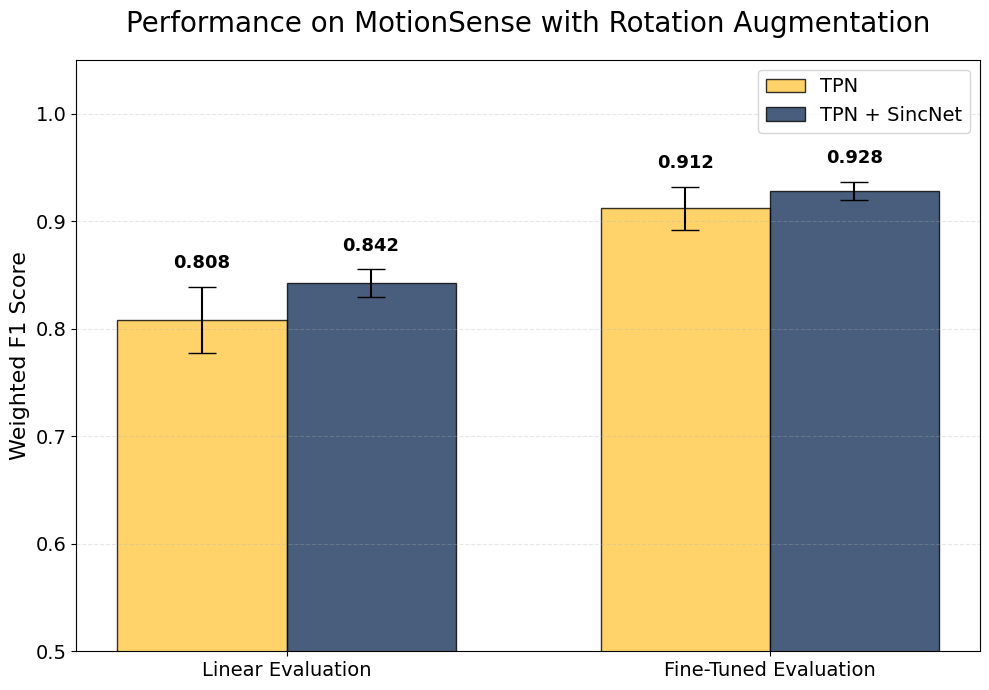

In [15]:
# MotionSense Rotation
plot_bars_performance(
    title='Performance on MotionSense with Rotation Augmentation',
    tpn_means=[0.808, 0.912],
    tpn_std=[0.031, 0.020],
    sincnet_means=[0.842, 0.928],
    sincnet_std=[0.013, 0.008]
)

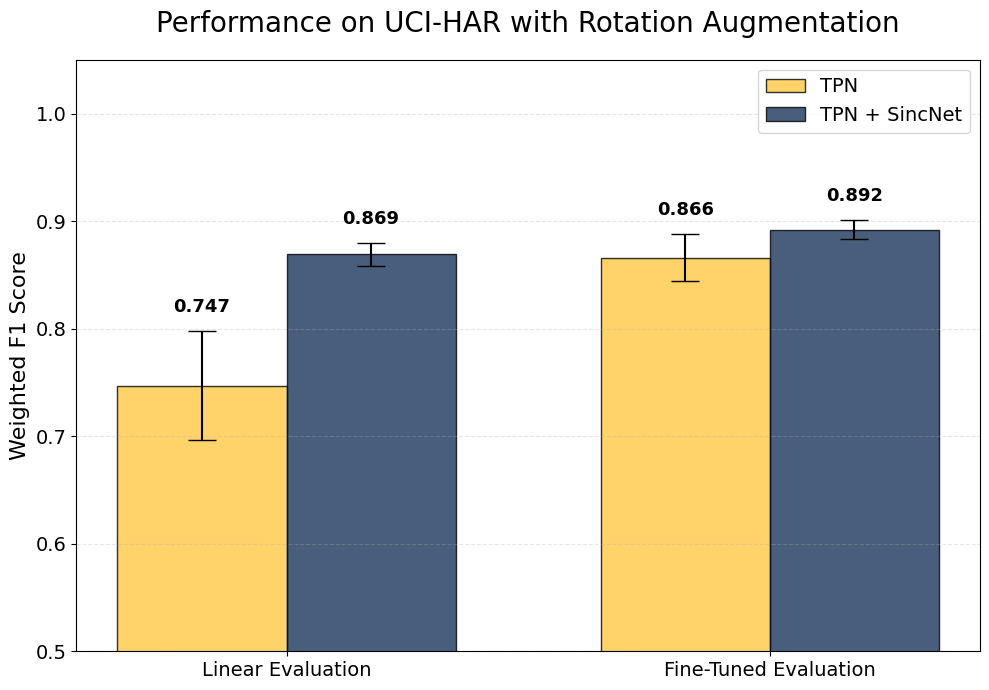

In [49]:
# UCI-HAR Rotation
plot_bars_performance(
    title='Performance on UCI-HAR with Rotation Augmentation',
    tpn_means=[0.747, 0.866],
    tpn_std=[0.051, 0.022],
    sincnet_means=[0.869, 0.892],
    sincnet_std=[0.011, 0.009]
)